## Applying CNN to an image

In [5]:
###### An image and apply th convolutional layer, activation layer operation to extract the inside feature.
###### Steps:
###### import the necessary libraries
###### set the parameters
###### define the kernel
###### load the image and plot it
###### reformat the image
###### apply convolutional layer operation and plot the output image.
###### apply activation layer operation and plot the output image.
###### apply pooling layer operation and plot the output image.

In [6]:
# import the necessary libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from itertools import product

In [7]:
#set the param
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')

In [8]:
#define the kernel
kernel = tf.constant([[-1,-1,-1],
                     [-1,8,-1],
                     [-1,-1,-1]
                     ])
#load the image
image = tf.io.read_file('Ganesh.jpeg')
image = tf.io.decode_jpeg(image,channels=1)
image = tf.image.resize(image,size=[300,300])

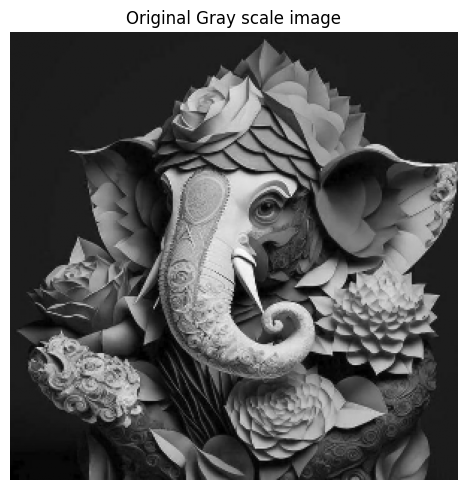

In [9]:
#plot the image
img=tf.squeeze(image).numpy()
plt.figure(figsize=(5,5))
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.title('Original Gray scale image')
plt.show()

In [10]:
# Reformat
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel=tf.reshape(kernel, [*kernel.shape,1,1])
kernel=tf.cast(kernel,dtype=tf.float32)

In [11]:
#convolutional layer
conv_fn= tf.nn.conv2d
image_filter=conv_fn(input=image, filters=kernel, strides=1,
                     padding='SAME')
plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Convolution')

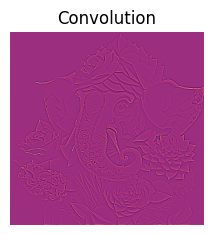

In [12]:
#plot the convolved image
plt.subplot(1,3,1)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Convolution')

Text(0.5, 1.0, 'Activation')

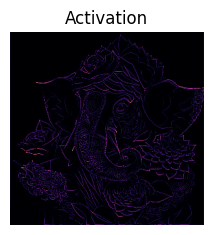

In [13]:
#activation layer
relu_fn=tf.nn.relu

#image detection
image_detect=relu_fn(image_filter)
plt.subplot(1,3,2)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Activation')

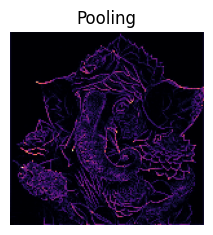

In [14]:
#pooling layers
pool = tf.nn.pool
image_condense=pool(input=image_detect, window_shape=(2,2),
                    pooling_type='MAX', 
                    strides=(2,2),
                    padding='SAME')
plt.subplot(1,3,3)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title('Pooling')
plt.show()